# RoomBeacon — Kỹ thuật dữ liệu, EDA & Xây dựng đặc trưng

Notebook này là quy trình kỹ thuật dữ liệu có thể tái lập cho tập tin đăng trạng thái mới nhất của RoomBeacon.
Notebook tạo ra tập dữ liệu sẵn sàng cho feature engineering, có thể kiểm toán; chủ động dừng trước phần mô hình
vì chưa có mục tiêu dự báo và chính sách chia dữ liệu được phê duyệt.

> Tên biến và tên cột được giữ bằng tiếng Anh để nhất quán với mã nguồn, SQL và pipeline sản xuất.


## 01. Bài toán & Hiểu dữ liệu


### 01.1 Định nghĩa bài toán

Dữ liệu crawler từ nhiều nguồn có mức độ bao phủ và chất lượng parser khác nhau. Nhiệm vụ kỹ thuật là giữ được
khả năng truy vết dữ liệu thô, đồng thời tạo một tập phân tích đã xác thực và không làm mất dòng dữ liệu.


### 01.2 Mục tiêu và tiêu chí thành công

**Mục tiêu:** kiểm định chất lượng dữ liệu thô, áp dụng các quy tắc làm sạch minh bạch và công bố metadata cho đặc trưng.

**Thành công:** mỗi tin đăng chỉ có một dòng trạng thái mới nhất, dữ liệu thô bất biến, không mất dòng khi làm sạch,
có bằng chứng trước/sau cho các trường quan trọng và không có giá trị đặc trưng vô hạn.


### 01.3 Đơn vị quan sát, mục tiêu và giả định

- **Đơn vị quan sát:** một `rental_post_id` tại lần quan sát gần nhất.
- **Mục tiêu dự báo:** chưa được xác định. Notebook không chia train/test, không chọn đặc trưng theo target và không huấn luyện mô hình.
- **Giả định:** giá là VND/tháng, diện tích là m², và ánh xạ địa điểm có nhiều hơn một kết quả được giữ là mơ hồ.


## 02. Môi trường & Khả năng tái lập


### 02.1 Đường dẫn dự án và môi trường chạy


In [1]:
import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from utils import setup_project_path
except ModuleNotFoundError:
    from notebooks.utils import setup_project_path

PROJECT_ROOT = setup_project_path()
NOTEBOOKS_ROOT = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "data" / ".cache" / "matplotlib"))


Đã phát hiện thư mục gốc của dự án RoomBeacon: /mnt/Data/projects/roombeacon


'/mnt/Data/projects/roombeacon/data/.cache/matplotlib'

### 02.2 Import thư viện


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import Markdown, display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

load_dotenv(PROJECT_ROOT / ".env", override=False)


True

### 02.3 Tiện ích của dự án


In [3]:
from analytics.duckdb.connection import create_analytics_connection
from utils.address_cleaner import clean_address
from utils.area_validator import MAX_AREA_M2, MIN_AREA_M2, classify_area_band, validate_area
from utils.location_normalizer import normalize_location
from utils.price_validator import MAX_PRICE_VND, MIN_PRICE_VND, classify_price_band, validate_price


### 02.4 Cấu hình dùng chung


In [4]:
RANDOM_SEED = 42
CLEANING_RULE_VERSION = "eda-prep-v1.0"
PALETTE = {"raw": "#C75B5B", "clean": "#2A9D8F", "neutral": "#457B9D"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


### 02.5 Dòng chảy dữ liệu


In [5]:
pipeline_nodes = [
    ("MySQL Bronze", "quan sát bất biến"),
    ("Trạng thái mới nhất DuckDB", "một dòng / tin đăng"),
    ("df_raw", "dữ liệu đầu vào chỉ đọc để kiểm định"),
    ("df_clean", "dữ liệu sạch bảo toàn dòng"),
    ("df_feature_ready", "tập dữ liệu bàn giao"),
]


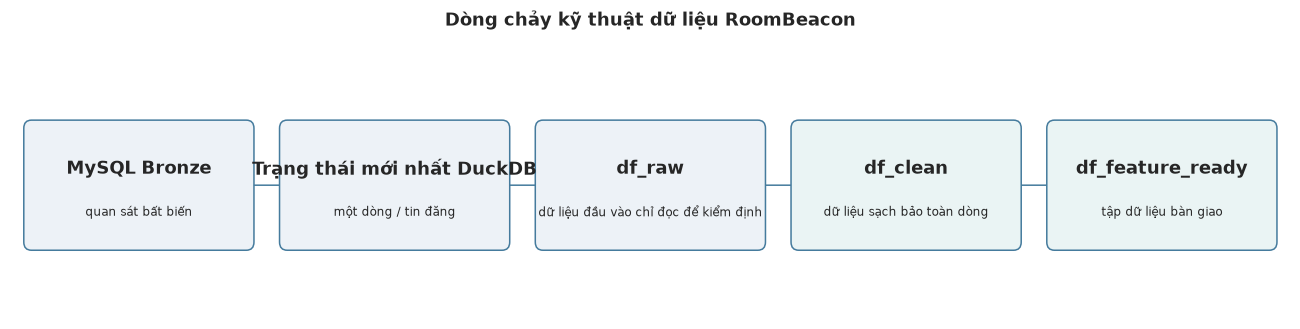

In [6]:
figure, axis = plt.subplots(figsize=(15, 3.2))
axis.set(xlim=(0, len(pipeline_nodes)), ylim=(0, 1))
axis.axis("off")

for index, (title, subtitle) in enumerate(pipeline_nodes):
    x_position = index + 0.08
    axis.add_patch(FancyBboxPatch((x_position, 0.28), 0.84, 0.42, boxstyle="round,pad=0.03", facecolor="#EAF4F4" if index >= 3 else "#EDF2F7", edgecolor="#457B9D"))
    axis.text(x_position + 0.42, 0.55, title, ha="center", va="center", weight="bold")
    axis.text(x_position + 0.42, 0.39, subtitle, ha="center", va="center", fontsize=8)
    if index < len(pipeline_nodes) - 1:
        axis.add_patch(FancyArrowPatch((x_position + 0.86, 0.49), (x_position + 1.05, 0.49), arrowstyle="->", mutation_scale=14, color="#457B9D"))

axis.set_title("Dòng chảy kỹ thuật dữ liệu RoomBeacon", pad=14)
plt.show()


## 03. Nạp dữ liệu


### 03.1 Đường dẫn truy vấn và hợp đồng dữ liệu đầu vào


In [7]:
EDA_QUERY_PATH = PROJECT_ROOT / "notebooks" / "sql" / "eda_latest_posts.sql"
REQUIRED_INPUT_COLUMNS = {
    "source", "rental_post_id", "listing_id", "title_raw", "url", "price", "area", "address",
    "full_address_inherited", "observed_at", "first_observed_at", "last_observed_at", "active_days",
}


### 03.2 Nạp dữ liệu trạng thái mới nhất dạng thô


In [8]:
eda_query = EDA_QUERY_PATH.read_text(encoding="utf-8")
analytics_connection = create_analytics_connection()
df_raw = analytics_connection.sql(eda_query).df()
print(f"Đã nạp {len(df_raw):,} tin đăng ở trạng thái mới nhất")


Đã nạp 47,753 tin đăng ở trạng thái mới nhất


### 03.3 Xác thực schema và định danh


In [9]:
missing_columns = REQUIRED_INPUT_COLUMNS.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f"Truy vấn EDA thiếu cột bắt buộc: {sorted(missing_columns)}")
if df_raw.empty:
    raise ValueError("Truy vấn EDA không trả về dòng nào; hãy kiểm tra MySQL Bronze và kết nối DuckDB.")
if df_raw["rental_post_id"].isna().any() or df_raw["rental_post_id"].duplicated().any():
    raise ValueError("Vi phạm hợp đồng dữ liệu: rental_post_id phải hiện diện và duy nhất.")
print("✓ Đã đạt hợp đồng schema và định danh tin đăng mới nhất")


✓ Đã đạt hợp đồng schema và định danh tin đăng mới nhất


### 03.4 Metadata của lần chụp dữ liệu


In [10]:
snapshot_metadata = pd.DataFrame(
    {"giá_trị": [datetime.now(timezone.utc).isoformat(), len(df_raw), df_raw["source"].nunique(), EDA_QUERY_PATH.relative_to(PROJECT_ROOT).as_posix()]},
    index=["thời_điểm_nạp_utc", "số_dòng", "nguồn", "truy_vấn"],
)
display(snapshot_metadata)


,giá_trị
thời_điểm_nạp_utc,2026-09-07T13:30:28.144151+00:00
số_dòng,47753
nguồn,8
truy_vấn,notebooks/sql/eda_latest_posts.sql


### 03.5 Kích thước tập dữ liệu và mẫu bản ghi


In [11]:
print(f"Kích thước: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
display(df_raw.sample(min(5, len(df_raw)), random_state=RANDOM_SEED))


Kích thước: 47,753 dòng × 14 cột


,source,rental_post_id,listing_id,title_raw,url,price,area,area_inherited,address,full_address_inherited,observed_at,first_observed_at,last_observed_at,active_days
24138,chothuephongtro,71703,ho-chi-minh/quan-7/159637,CĂN DUPLEX ĐẸP NHƯ TRANH NGAY TRUNG TÂM Q7,https://chothuephongtro.me/ho-chi-minh/quan-7/...,"9,500,000.00",35.00,False,"Quận 7, Hồ Chí Minh",False,2026-09-07 07:20:21,2026-09-07 07:20:21,2026-09-07 07:20:21,0
8582,chothuephongtro,90,169564,"Cho Thuê Phòng Trọ Có Gác Giá Rẻ HSSV Gần UFM,...",https://chothuephongtro.me/cho-thue-phong-tro-...,"4,800,000.00",40.00,False,"Tân Bình, Hồ Chí Minh",True,2026-09-07 12:10:03,2026-09-06 10:19:48,2026-09-07 12:10:03,1
42026,phongtro123,17775,688863,"Phòng trọ giá rẻ gần các trường đại học UEH, Y...",https://phongtro123.com/phong-tro-gia-re-gan-c...,"5,500,000.00",30.00,False,NaN,False,2026-09-06 17:52:39,2026-09-06 12:38:00,2026-09-06 17:52:39,0
24963,phongtro123,70921,644422,Trống Phòng Full Nội Thất - Mặt Tiền Trường Chinh,https://phongtro123.com/trong-phong-full-noi-t...,"3,600,000.00",26.00,False,"Quận 12, Hồ Chí Minh",False,2026-09-07 07:08:10,2026-09-07 07:08:10,2026-09-07 07:08:10,0
45651,phongtro123,13385,696599,CHO THUÊ PHÒNG GÁC SIU ĐẸP TIỆN NGHI TẠI TÂN B...,https://phongtro123.com/phong-gac-siu-dep-tien...,"4,000,000.00",25.00,False,"Tân Bình, Hồ Chí Minh",False,2026-09-06 17:07:58,2026-09-06 11:52:41,2026-09-06 17:07:58,0


### 03.6 Tổng quan schema


In [12]:
schema_overview = pd.DataFrame({"column": df_raw.columns, "dtype": df_raw.dtypes.astype(str)})
display(schema_overview)


,column,dtype
source,source,str
rental_post_id,rental_post_id,int64
listing_id,listing_id,str
title_raw,title_raw,str
url,url,str
price,price,float64
area,area,float64
area_inherited,area_inherited,bool
address,address,str
full_address_inherited,full_address_inherited,bool


### 03.7 Xác định vai trò các cột


In [13]:
identifier_columns = ["rental_post_id", "listing_id", "url"]
numerical_columns = [column for column in ("price", "area", "active_days") if column in df_raw.columns]
categorical_columns = [column for column in ("source", "full_address_inherited") if column in df_raw.columns]
datetime_columns = [column for column in ("observed_at", "first_observed_at", "last_observed_at") if column in df_raw.columns]
target_column = None


In [14]:
column_roles = pd.DataFrame(
    [(column, "định danh") for column in identifier_columns]
    + [(column, "số học") for column in numerical_columns]
    + [(column, "phân loại") for column in categorical_columns]
    + [(column, "thời gian") for column in datetime_columns],
    columns=["column", "role"],
)
display(column_roles)


,column,role
0,rental_post_id,định danh
1,listing_id,định danh
2,url,định danh
3,price,số học
4,area,số học
5,active_days,số học
6,source,phân loại
7,full_address_inherited,phân loại
8,observed_at,thời gian
9,first_observed_at,thời gian


### 03.8 Từ điển dữ liệu


In [15]:
data_dictionary = schema_overview.merge(column_roles, on="column", how="left")
data_dictionary["role"] = data_dictionary["role"].fillna("thuộc tính thô")
display(data_dictionary)


,column,dtype,role
0,source,str,phân loại
1,rental_post_id,int64,định danh
2,listing_id,str,định danh
3,title_raw,str,thuộc tính thô
4,url,str,định danh
5,price,float64,số học
6,area,float64,số học
7,area_inherited,bool,thuộc tính thô
8,address,str,thuộc tính thô
9,full_address_inherited,bool,phân loại


## 04. Kiểm định chất lượng dữ liệu


### 04.1 Hàm hỗ trợ kiểm định


In [16]:
def non_empty(series: pd.Series) -> pd.Series:
    return series.notna() & series.astype("string").str.strip().ne("")


def finite_quantile(series: pd.Series, quantile: float) -> float | None:
    values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return float(values.quantile(quantile)) if not values.empty else None


### 04.2 Cờ xác định dữ liệu hiện diện


In [17]:
raw_presence = pd.DataFrame(
    {"price": df_raw["price"].notna(), "area": df_raw["area"].notna(), "address": non_empty(df_raw["address"]), "title": non_empty(df_raw["title_raw"])}
)


### 04.3 Giá trị thiếu


In [18]:
missing_audit = pd.DataFrame({"missing_count": df_raw.isna().sum(), "missing_pct": (df_raw.isna().mean() * 100).round(2)})
missing_audit = missing_audit.sort_values("missing_pct", ascending=False)
display(missing_audit)


,missing_count,missing_pct
address,6842,14.33
area,1056,2.21
price,732,1.53
title_raw,194,0.41
rental_post_id,0,0.00
source,0,0.00
url,0,0.00
listing_id,0,0.00
area_inherited,0,0.00
full_address_inherited,0,0.00


### 04.4 Biểu đồ giá trị thiếu


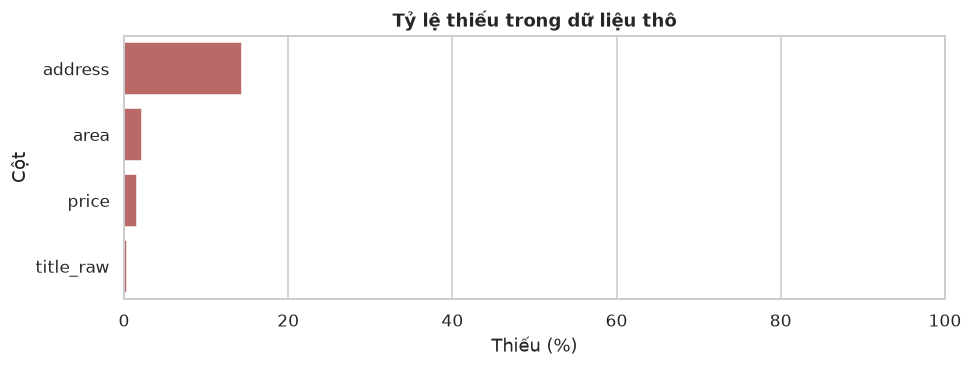

In [19]:
missing_to_plot = missing_audit.query("missing_count > 0").reset_index(names="cột")
if not missing_to_plot.empty:
    figure, axis = plt.subplots(figsize=(9, max(3.5, len(missing_to_plot) * 0.4)))
    sns.barplot(data=missing_to_plot, y="cột", x="missing_pct", color=PALETTE["raw"], ax=axis)
    axis.set(title="Tỷ lệ thiếu trong dữ liệu thô", xlabel="Thiếu (%)", ylabel="Cột", xlim=(0, 100))
    plt.tight_layout()
    plt.show()


### 04.5 Bản ghi trùng lặp


In [20]:
duplicate_listing_count = int(df_raw.duplicated(subset=["rental_post_id"]).sum())
duplicate_exact_count = int(df_raw.duplicated().sum())
display(pd.DataFrame({"check": ["rental_post_id trùng", "dòng trùng hoàn toàn"], "số_lượng": [duplicate_listing_count, duplicate_exact_count]}))


,check,số_lượng
0,rental_post_id trùng,0
1,dòng trùng hoàn toàn,0


### 04.6 Phân tích lực lượng (cardinality)


In [21]:
cardinality_audit = pd.DataFrame({"giá_trị_khác_nhau": df_raw.nunique(dropna=True), "tỷ_lệ_khác_nhau_pct": (df_raw.nunique(dropna=True) / len(df_raw) * 100).round(2)})
cardinality_audit = cardinality_audit.sort_values("giá_trị_khác_nhau", ascending=False)
display(cardinality_audit)


,giá_trị_khác_nhau,tỷ_lệ_khác_nhau_pct
rental_post_id,47753,100.00
listing_id,47753,100.00
url,47753,100.00
title_raw,46253,96.86
first_observed_at,11002,23.04
observed_at,10954,22.94
last_observed_at,10954,22.94
address,3277,6.86
price,367,0.77
area,207,0.43


### 04.7 Trường hằng và gần hằng


In [22]:
constant_columns = cardinality_audit.index[cardinality_audit["giá_trị_khác_nhau"].le(1)].tolist()
top_value_share = df_raw.apply(lambda column: column.value_counts(dropna=False, normalize=True).max()).sort_values(ascending=False)
near_constant_columns = top_value_share.index[top_value_share.ge(0.995)].tolist()
display(pd.DataFrame({"cột_hằng": [constant_columns], "cột_gần_hằng": [near_constant_columns]}))


,cột_hằng,cột_gần_hằng
0,[],[]


### 04.8 Giá trị không hợp lệ và bất khả thi


In [23]:
raw_issue_summary = pd.DataFrame(
    {"quy_tắc": ["giá không hợp lệ", "diện tích không hợp lệ", "địa chỉ thiếu/trống", "tiêu đề thiếu/trống"],
     "tin_bị_ảnh_hưởng": [
         int((df_raw["price"].notna() & ~df_raw["price"].map(validate_price)).sum()),
         int((df_raw["area"].notna() & ~df_raw["area"].map(validate_area)).sum()),
         int((~raw_presence["address"]).sum()), int((~raw_presence["title"]).sum()),
     ]}
)
raw_issue_summary["tỷ_lệ_ảnh_hưởng_pct"] = raw_issue_summary["tin_bị_ảnh_hưởng"] / len(df_raw) * 100
display(raw_issue_summary)


,quy_tắc,tin_bị_ảnh_hưởng,tỷ_lệ_ảnh_hưởng_pct
0,giá không hợp lệ,7,0.01
1,diện tích không hợp lệ,352,0.74
2,địa chỉ thiếu/trống,6842,14.33
3,tiêu đề thiếu/trống,194,0.41


### 04.9 Rủi ro rò rỉ dữ liệu và các cột loại trừ khi mô hình hóa


In [24]:
excluded_from_future_model_features = identifier_columns + datetime_columns
leakage_audit = pd.DataFrame({"trường": excluded_from_future_model_features, "lý_do": ["định danh / truy vết"] * len(identifier_columns) + ["thời điểm snapshot"] * len(datetime_columns)})
display(leakage_audit)
print("Target chưa được xác định: không thực hiện thao tác học có giám sát.")


,trường,lý_do
0,rental_post_id,định danh / truy vết
1,listing_id,định danh / truy vết
2,url,định danh / truy vết
3,observed_at,thời điểm snapshot
4,first_observed_at,thời điểm snapshot
5,last_observed_at,thời điểm snapshot


Target chưa được xác định: không thực hiện thao tác học có giám sát.


### 04.10 Tóm tắt chất lượng


In [25]:
quality_audit_summary = pd.DataFrame({"chỉ_số": ["số dòng", "số nguồn", "ID tin đăng trùng", "trường hằng", "thiếu giá", "thiếu diện tích", "thiếu địa chỉ"], "giá_trị": [len(df_raw), df_raw["source"].nunique(), duplicate_listing_count, len(constant_columns), int((~raw_presence["price"]).sum()), int((~raw_presence["area"]).sum()), int((~raw_presence["address"]).sum())]})
display(quality_audit_summary)


,chỉ_số,giá_trị
0,số dòng,47753
1,số nguồn,8
2,ID tin đăng trùng,0
3,trường hằng,0
4,thiếu giá,732
5,thiếu diện tích,1056
6,thiếu địa chỉ,6842


## 05. Phân tích khám phá dữ liệu — Trước làm sạch


### 05.1 Thống kê số học và độ lệch


In [26]:
raw_numeric_summary = df_raw[["price", "area", "active_days"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
raw_numeric_summary["skew"] = df_raw[["price", "area", "active_days"]].skew(numeric_only=True)
display(raw_numeric_summary)


,count,mean,std,min,1%,25%,50%,75%,99%,max,skew
price,"47,021.00","4,459,064.41","43,454,753.47","2,500.00","1,000,000.00","3,000,000.00","4,000,000.00","5,000,000.00","10,000,000.00","8,500,000,000.00",175.53
area,"46,697.00",33.68,51.78,1.00,8.00,22.00,28.00,35.00,200.00,"2,040.00",12.93
active_days,"47,753.00",0.51,0.50,0.00,0.00,0.00,1.00,1.00,1.00,1.00,-0.03


### 05.2 Phân bố nguồn dữ liệu


In [27]:
source_counts = df_raw["source"].value_counts().sort_values()
source_coverage_before = raw_presence.astype("float64").assign(source=df_raw["source"]).groupby("source", observed=True).mean().mul(100).sort_index()


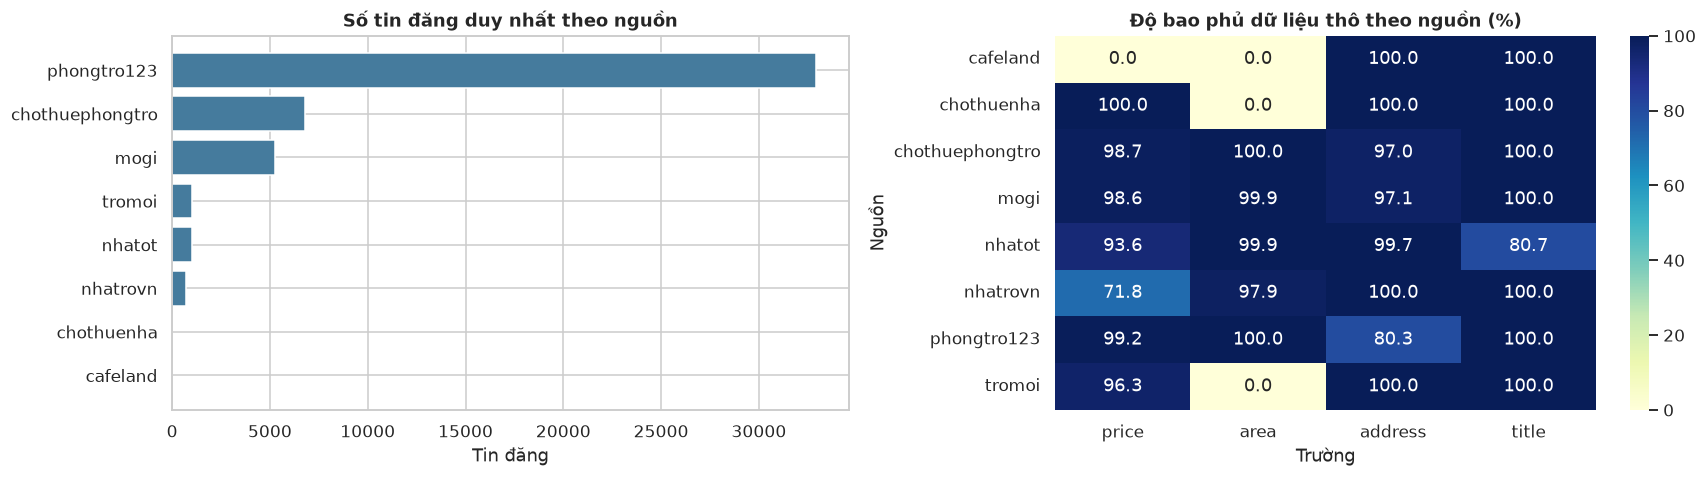

In [28]:
figure, axes = plt.subplots(1, 2, figsize=(16, max(4.5, len(source_counts) * 0.45)))
axes[0].barh(source_counts.index, source_counts.values, color=PALETTE["neutral"])
axes[0].set(title="Số tin đăng duy nhất theo nguồn", xlabel="Tin đăng")
sns.heatmap(source_coverage_before, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=100, ax=axes[1])
axes[1].set(title="Độ bao phủ dữ liệu thô theo nguồn (%)", xlabel="Trường", ylabel="Nguồn")
plt.tight_layout()
plt.show()


### 05.3 Phân bố giá và diện tích thô


In [29]:
raw_price_million = df_raw["price"] / 1_000_000
raw_area_m2 = df_raw["area"]
price_limit = finite_quantile(raw_price_million, 0.99)
area_limit = finite_quantile(raw_area_m2, 0.99)


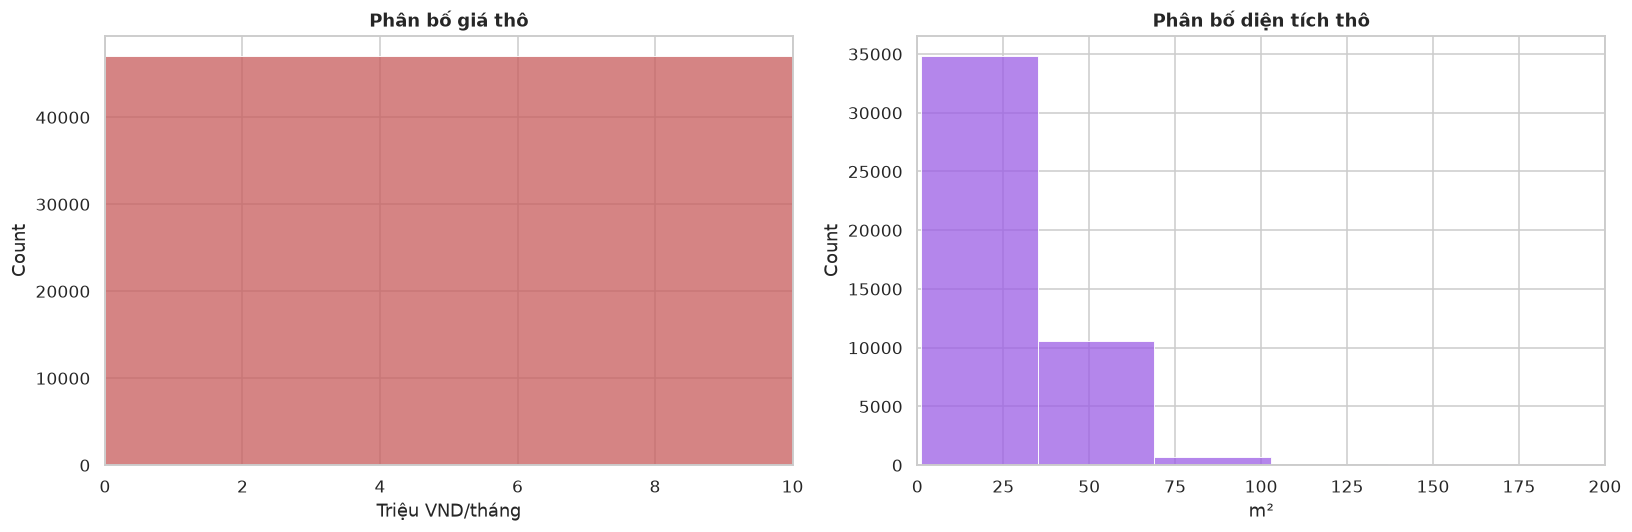

In [30]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(raw_price_million.dropna(), bins=60, color=PALETTE["raw"], ax=axes[0])
axes[0].set(title="Phân bố giá thô", xlabel="Triệu VND/tháng")
sns.histplot(raw_area_m2.dropna(), bins=60, color="#9B5DE5", ax=axes[1])
axes[1].set(title="Phân bố diện tích thô", xlabel="m²")
if price_limit is not None: axes[0].set_xlim(0, price_limit)
if area_limit is not None: axes[1].set_xlim(0, area_limit)
plt.tight_layout()
plt.show()


### 05.4 Giá thô × diện tích


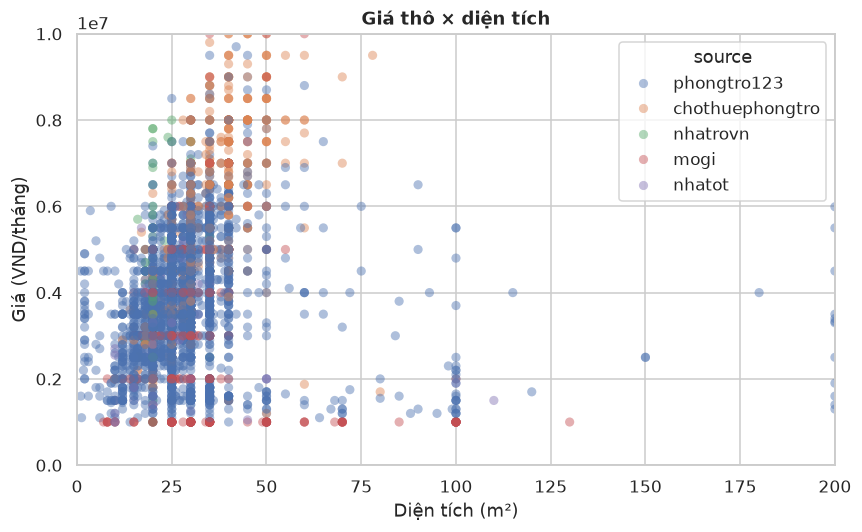

In [31]:
raw_price_area = df_raw.dropna(subset=["price", "area"])
if len(raw_price_area) >= 2:
    figure, axis = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=raw_price_area.sample(min(len(raw_price_area), 5_000), random_state=RANDOM_SEED), x="area", y="price", hue="source", alpha=0.45, linewidth=0, ax=axis)
    axis.set(title="Giá thô × diện tích", xlabel="Diện tích (m²)", ylabel="Giá (VND/tháng)")
    axis.set_xlim(0, finite_quantile(raw_price_area["area"], 0.99))
    axis.set_ylim(0, finite_quantile(raw_price_area["price"], 0.99))
    plt.tight_layout()
    plt.show()


### 05.5 Khoảng thời gian


In [32]:
raw_time_columns = df_raw[datetime_columns].apply(pd.to_datetime, utc=True, errors="coerce")
time_audit = pd.DataFrame({"min": raw_time_columns.min(), "max": raw_time_columns.max(), "missing": raw_time_columns.isna().sum()})
display(time_audit)


,min,max,missing
observed_at,2026-09-06 10:19:41+00:00,2026-09-07 13:20:17+00:00,0
first_observed_at,2026-09-06 10:19:35+00:00,2026-09-07 13:20:10+00:00,0
last_observed_at,2026-09-06 10:19:41+00:00,2026-09-07 13:20:17+00:00,0


### 05.6 Phát hiện: Câu hỏi → Bằng chứng → Nhận định → Quyết định


In [33]:
price_skew = raw_price_million.dropna().skew()
invalid_price_count = int((df_raw["price"].notna() & ~df_raw["price"].map(validate_price)).sum())
display(Markdown(f"**Câu hỏi:** Có thể dùng trực tiếp giá thô không?<br>**Bằng chứng:** độ lệch = `{price_skew:.2f}`; số dòng giá không hợp lệ = `{invalid_price_count:,}`.<br>**Nhận định:** giá trị thô có thể bị méo bởi các bản ghi không hợp lý.<br>**Quyết định:** giữ dữ liệu thô để kiểm toán và tạo `price_clean_vnd` cho EDA phía sau."))


**Câu hỏi:** Có thể dùng trực tiếp giá thô không?<br>**Bằng chứng:** độ lệch = `175.53`; số dòng giá không hợp lệ = `7`.<br>**Nhận định:** giá trị thô có thể bị méo bởi các bản ghi không hợp lý.<br>**Quyết định:** giữ dữ liệu thô để kiểm toán và tạo `price_clean_vnd` cho EDA phía sau.

## 06. Làm sạch dữ liệu


### 06.1 Quy tắc làm sạch có phiên bản


In [34]:
cleaning_rules = pd.DataFrame(
    [("price_clean_vnd", f"{MIN_PRICE_VND:,.0f} ≤ price ≤ {MAX_PRICE_VND:,.0f} VND/month", "không hợp lệ → NA"),
     ("area_clean_m2", f"{MIN_AREA_M2:g} ≤ area ≤ {MAX_AREA_M2:,.0f} m²", "không hợp lệ → NA"),
     ("address_clean", "cắt khoảng trắng và chuẩn hóa định dạng địa chỉ", "trống → NA"),
     ("current_location", "chỉ có đúng một địa điểm sau chuẩn hóa", "mơ hồ → NA")],
    columns=["cột_đầu_ra", "quy_tắc", "xử_lý"],
)
display(cleaning_rules)


,cột_đầu_ra,quy_tắc,xử_lý
0,price_clean_vnd,"300,000 ≤ price ≤ 200,000,000 VND/month",không hợp lệ → NA
1,area_clean_m2,"5 ≤ area ≤ 1,000 m²",không hợp lệ → NA
2,address_clean,cắt khoảng trắng và chuẩn hóa định dạng địa chỉ,trống → NA
3,current_location,chỉ có đúng một địa điểm sau chuẩn hóa,mơ hồ → NA


### 06.2 Tạo bản sao làm việc có thể kiểm toán


In [35]:
df_quality = df_raw.copy(deep=True)
df_quality["cleaning_rule_version"] = CLEANING_RULE_VERSION


### 06.3 Làm sạch trường số


In [36]:
df_quality["price_is_valid"] = df_quality["price"].map(validate_price)
df_quality["area_is_valid"] = df_quality["area"].map(validate_area)
df_quality["price_clean_vnd"] = df_quality["price"].where(df_quality["price_is_valid"]).astype("Float64")
df_quality["area_clean_m2"] = df_quality["area"].where(df_quality["area_is_valid"]).astype("Float64")
df_quality["price_million_vnd"] = df_quality["price_clean_vnd"] / 1_000_000


### 06.4 Chuẩn hóa văn bản địa chỉ


In [37]:
df_quality["address_clean"] = df_quality["address"].map(clean_address).astype("string")
df_quality["address_is_present"] = non_empty(df_quality["address_clean"])


### 06.5 Chuẩn hóa địa điểm một cách thận trọng


In [38]:
df_quality["location_candidates"] = df_quality["address_clean"].map(normalize_location)
df_quality["location_candidate_count"] = df_quality["location_candidates"].map(len)
df_quality["location_mapping_status"] = np.select(
    [df_quality["address_clean"].isna(), df_quality["location_candidate_count"].eq(0), df_quality["location_candidate_count"].eq(1)],
    ["thiếu_địa_chỉ", "chưa_khớp", "đã_ánh_xạ"], default="mơ_hồ",
)
df_quality["current_location"] = df_quality["location_candidates"].map(lambda candidates: candidates[0] if len(candidates) == 1 else pd.NA).astype("string")


### 06.6 Tạo tập dữ liệu sạch bảo toàn dòng


In [39]:
clean_base_columns = ["source", "rental_post_id", "listing_id", "title_raw", "url", "price", "area", "address", "price_is_valid", "area_is_valid", "price_clean_vnd", "price_million_vnd", "area_clean_m2", "address_clean", "address_is_present", "current_location", "location_candidate_count", "location_mapping_status", "full_address_inherited", "observed_at", "first_observed_at", "last_observed_at", "active_days", "cleaning_rule_version"]
df_clean = df_quality.loc[:, list(dict.fromkeys(clean_base_columns))].copy()
assert len(df_clean) == len(df_raw), "Cleaning must preserve every listing row."


### 06.7 Bảng độ bao phủ trước/sau


In [40]:
quality_comparison = pd.DataFrame({"chỉ_số": ["giá", "diện tích", "địa chỉ", "ánh xạ một địa điểm"], "hiện_diện_trước": [raw_presence["price"].sum(), raw_presence["area"].sum(), raw_presence["address"].sum(), 0], "đáng_tin_cậy_sau": [df_clean["price_clean_vnd"].notna().sum(), df_clean["area_clean_m2"].notna().sum(), df_clean["address_clean"].notna().sum(), df_clean["current_location"].notna().sum()]})
quality_comparison["tỷ_lệ_trước_pct"] = quality_comparison["hiện_diện_trước"] / len(df_raw) * 100
quality_comparison["tỷ_lệ_sau_pct"] = quality_comparison["đáng_tin_cậy_sau"] / len(df_raw) * 100
display(quality_comparison)


,chỉ_số,hiện_diện_trước,đáng_tin_cậy_sau,tỷ_lệ_trước_pct,tỷ_lệ_sau_pct
0,giá,47021,47014,98.47,98.45
1,diện tích,46697,46345,97.79,97.05
2,địa chỉ,40911,40911,85.67,85.67
3,ánh xạ một địa điểm,0,5887,0.00,12.33


### 06.8 Biểu đồ độ bao phủ trước/sau


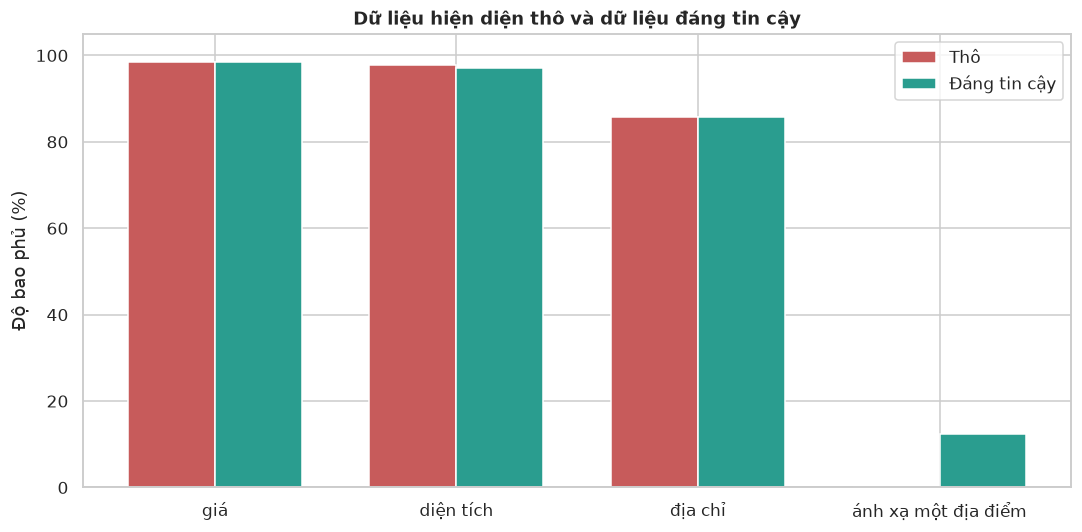

In [41]:
figure, axis = plt.subplots(figsize=(10, 5))
positions, width = np.arange(len(quality_comparison)), 0.36
axis.bar(positions - width / 2, quality_comparison["tỷ_lệ_trước_pct"], width, label="Thô", color=PALETTE["raw"])
axis.bar(positions + width / 2, quality_comparison["tỷ_lệ_sau_pct"], width, label="Đáng tin cậy", color=PALETTE["clean"])
axis.set(xticks=positions, xticklabels=quality_comparison["chỉ_số"], ylabel="Độ bao phủ (%)", ylim=(0, 105), title="Dữ liệu hiện diện thô và dữ liệu đáng tin cậy")
axis.legend()
plt.tight_layout()
plt.show()


### 06.9 Phân bố trước/sau


In [42]:
clean_price_million = df_clean["price_million_vnd"].dropna()
clean_area_m2 = df_clean["area_clean_m2"].dropna()


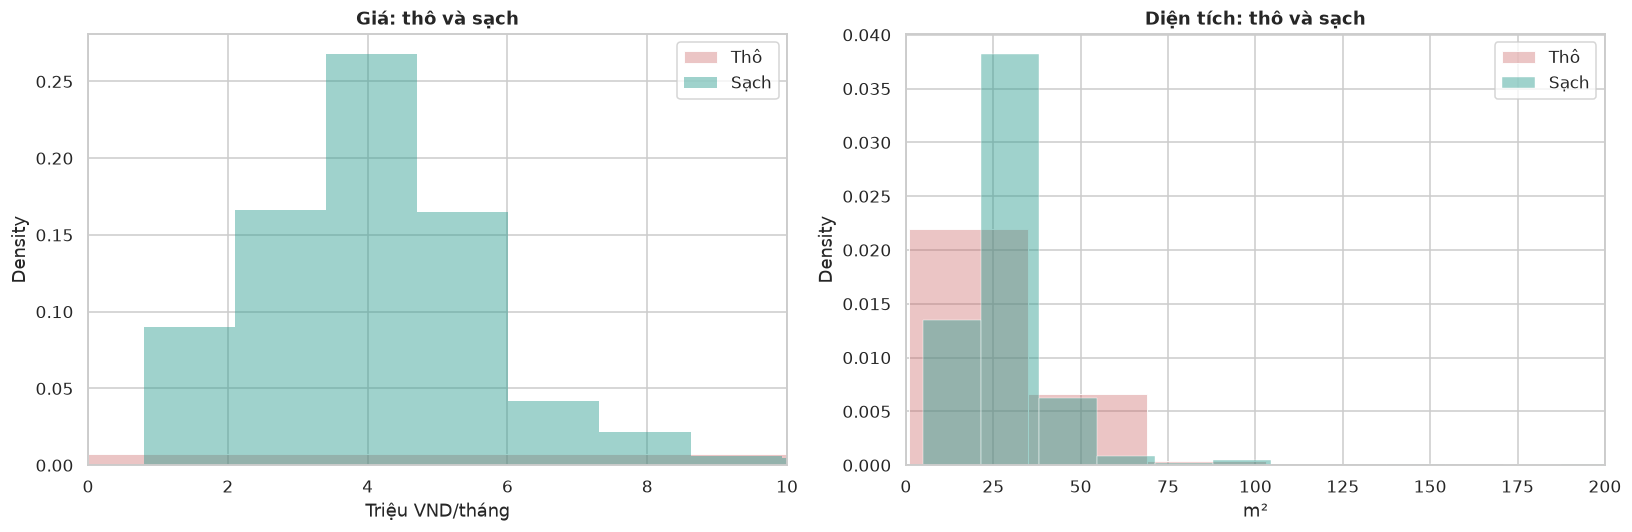

In [43]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, raw_values, clean_values, title, xlabel, limit in [(axes[0], raw_price_million, clean_price_million, "Giá", "Triệu VND/tháng", price_limit), (axes[1], raw_area_m2, clean_area_m2, "Diện tích", "m²", area_limit)]:
    sns.histplot(raw_values.dropna(), bins=60, stat="density", alpha=0.35, color=PALETTE["raw"], label="Thô", ax=axis)
    sns.histplot(clean_values, bins=60, stat="density", alpha=0.45, color=PALETTE["clean"], label="Sạch", ax=axis)
    axis.set(title=f"{title}: thô và sạch", xlabel=xlabel)
    axis.legend()
    if limit is not None: axis.set_xlim(0, limit)
plt.tight_layout()
plt.show()


### 06.10 Độ bao phủ đáng tin cậy theo nguồn


In [44]:
source_quality_after = df_clean.assign(price_trusted=df_clean["price_clean_vnd"].notna(), area_trusted=df_clean["area_clean_m2"].notna(), address_trusted=df_clean["address_clean"].notna(), location_mapped=df_clean["current_location"].notna()).groupby("source", observed=True)[["price_trusted", "area_trusted", "address_trusted", "location_mapped"]].mean().mul(100).sort_index()
display(source_quality_after.round(1))


,price_trusted,area_trusted,address_trusted,location_mapped
source,,,,
cafeland,0.00,0.00,100.00,0.00
chothuenha,100.00,0.00,100.00,80.00
chothuephongtro,98.60,100.00,97.00,13.70
mogi,98.60,99.90,97.10,20.20
nhatot,93.30,99.70,99.70,67.70
nhatrovn,71.80,97.80,100.00,66.60
phongtro123,99.20,98.90,80.30,7.30
tromoi,96.30,0.00,100.00,30.50


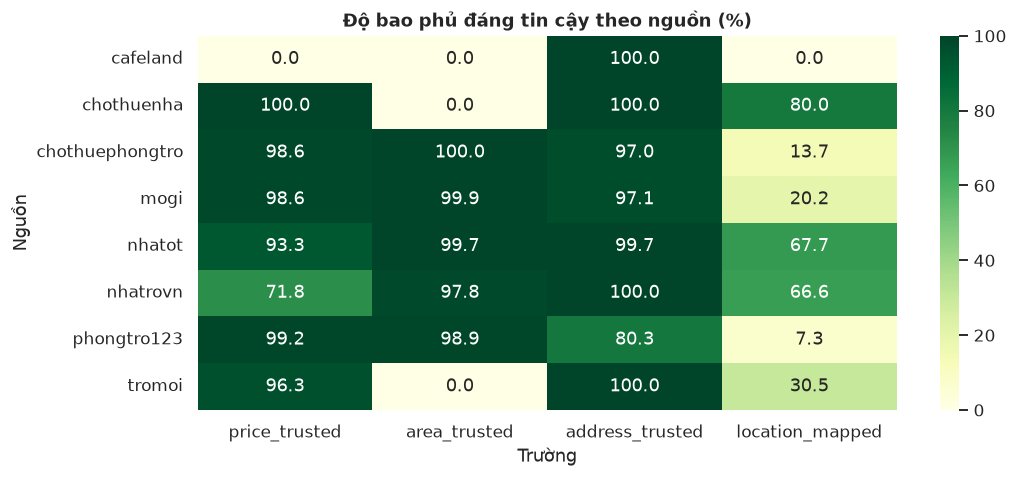

In [45]:
figure, axis = plt.subplots(figsize=(10, max(4.5, len(source_quality_after) * 0.45)))
sns.heatmap(source_quality_after, annot=True, fmt=".1f", cmap="YlGn", vmin=0, vmax=100, ax=axis)
axis.set(title="Độ bao phủ đáng tin cậy theo nguồn (%)", xlabel="Trường", ylabel="Nguồn")
plt.tight_layout()
plt.show()


### 06.11 Xác thực ranh giới làm sạch


In [46]:
assert len(df_clean) == len(df_raw)
assert "price_clean_vnd" not in df_raw.columns
assert not df_clean.loc[~df_clean["price_is_valid"], "price_clean_vnd"].notna().any()
assert not df_clean.loc[~df_clean["area_is_valid"], "area_clean_m2"].notna().any()
print("✓ Làm sạch bảo toàn số dòng và dữ liệu thô không bị thay đổi")


✓ Làm sạch bảo toàn số dòng và dữ liệu thô không bị thay đổi


## 07. Phân tích khám phá dữ liệu — Sau làm sạch


### 07.1 Xác định tập con phân tích sạch


In [47]:
df_market_clean = df_clean.loc[df_clean["price_clean_vnd"].notna() & df_clean["area_clean_m2"].notna()].copy()
print(f"Tập con sẵn sàng phân tích thị trường: {len(df_market_clean):,} / {len(df_clean):,} tin đăng ({len(df_market_clean) / len(df_clean):.1%})")


Tập con sẵn sàng phân tích thị trường: 45,652 / 47,753 tin đăng (95.6%)


### 07.2 Thống kê số học sau làm sạch


In [48]:
clean_numeric_summary = df_market_clean[["price_million_vnd", "area_clean_m2"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
clean_numeric_summary["skew"] = df_market_clean[["price_million_vnd", "area_clean_m2"]].skew(numeric_only=True)
display(clean_numeric_summary)


,count,mean,std,min,1%,25%,50%,75%,99%,max,skew
price_million_vnd,"45,652.00",4.18,2.00,0.80,1.00,3.00,4.00,5.00,10.00,79.00,5.89
area_clean_m2,"45,652.00",33.66,49.88,5.00,10.00,24.00,28.00,35.00,200.00,"1,000.00",11.89


### 07.3 Giá sạch × diện tích


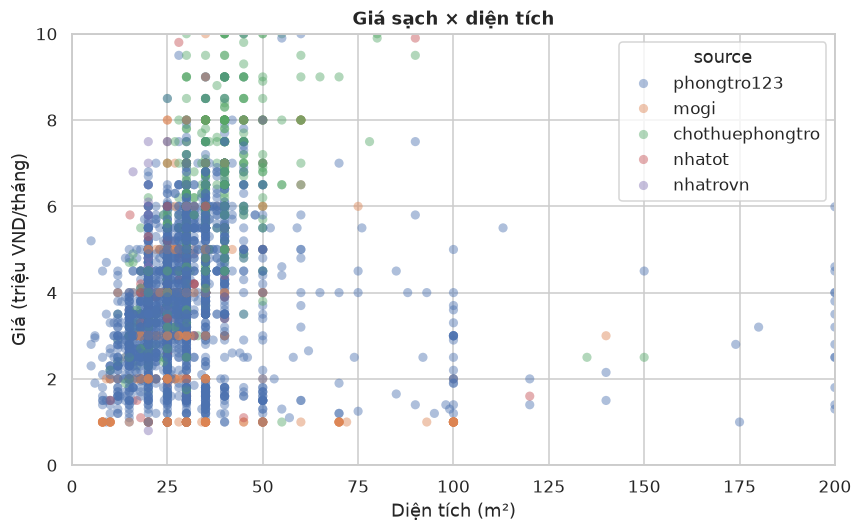

In [49]:
if len(df_market_clean) >= 2:
    figure, axis = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_market_clean.sample(min(len(df_market_clean), 5_000), random_state=RANDOM_SEED), x="area_clean_m2", y="price_million_vnd", hue="source", alpha=0.45, linewidth=0, ax=axis)
    axis.set(title="Giá sạch × diện tích", xlabel="Diện tích (m²)", ylabel="Giá (triệu VND/tháng)")
    axis.set_xlim(0, finite_quantile(df_market_clean["area_clean_m2"], 0.99))
    axis.set_ylim(0, finite_quantile(df_market_clean["price_million_vnd"], 0.99))
    plt.tight_layout()
    plt.show()


### 07.4 So sánh theo nguồn sau làm sạch


In [50]:
clean_source_summary = df_market_clean.groupby("source", observed=True).agg(listings=("rental_post_id", "nunique"), median_price_million=("price_million_vnd", "median"), median_area_m2=("area_clean_m2", "median")).sort_values("median_price_million", ascending=False).reset_index()
display(clean_source_summary)


,source,listings,median_price_million,median_area_m2
0,chothuephongtro,6707,5.80,35.00
1,nhatrovn,508,4.50,20.00
2,phongtro123,32324,3.90,26.00
3,nhatot,933,3.70,25.00
4,mogi,5180,3.00,30.00


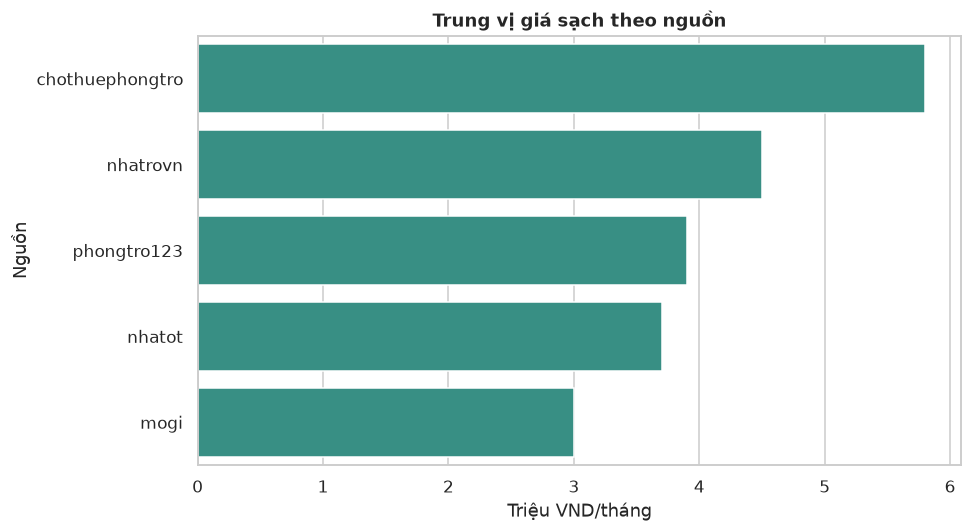

In [51]:
if not clean_source_summary.empty:
    figure, axis = plt.subplots(figsize=(9, 5))
    sns.barplot(data=clean_source_summary, y="source", x="median_price_million", color=PALETTE["clean"], ax=axis)
    axis.set(title="Trung vị giá sạch theo nguồn", xlabel="Triệu VND/tháng", ylabel="Nguồn")
    plt.tight_layout()
    plt.show()


### 07.5 Phân bố địa điểm sau làm sạch


In [52]:
location_summary = df_clean.dropna(subset=["current_location"]).groupby("current_location", observed=True).agg(listings=("rental_post_id", "nunique"), median_price_million=("price_million_vnd", "median")).sort_values("listings", ascending=False).head(15).reset_index()
display(location_summary)


,current_location,listings,median_price_million
0,Phường Tân Mỹ,3011,3.50
1,Phường Phú Thạnh,575,4.10
2,Phường Tân Hưng,139,4.60
3,Phường Đông Hưng Thuận,110,3.10
4,Phường Tân Bình,100,4.00
5,Phường Trung Mỹ Tây,84,3.00
6,Phường An Nhơn,83,4.00
7,Phường Thạnh Mỹ Tây,74,5.00
8,Phường Bình Lợi Trung,71,4.80
9,Phường Thông Tây Hội,67,3.95


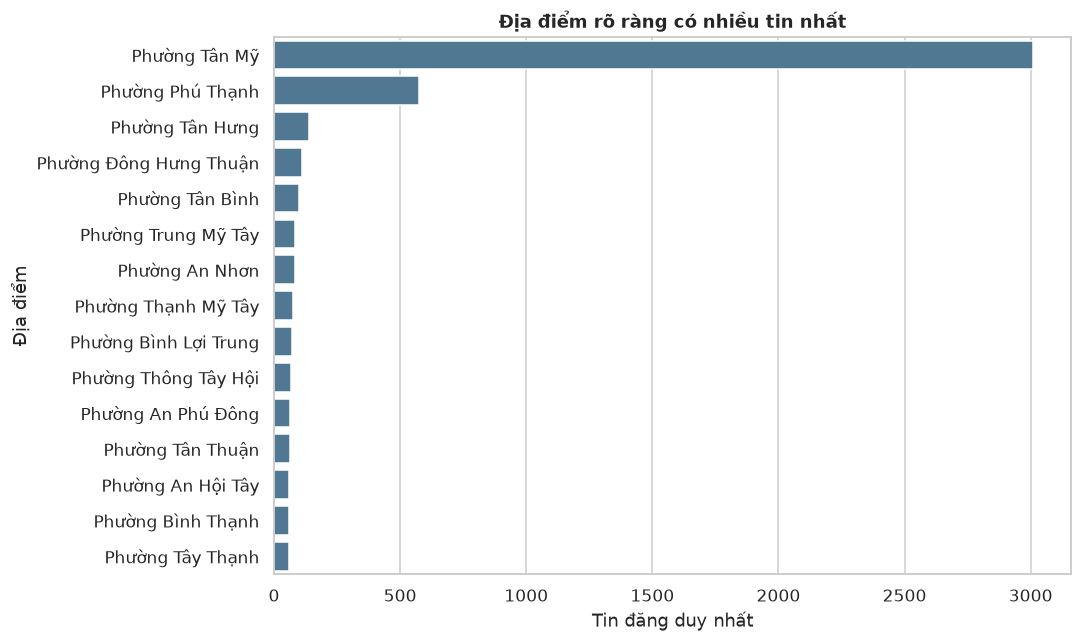

In [53]:
if not location_summary.empty:
    figure, axis = plt.subplots(figsize=(10, 6))
    sns.barplot(data=location_summary, y="current_location", x="listings", color=PALETTE["neutral"], ax=axis)
    axis.set(title="Địa điểm rõ ràng có nhiều tin nhất", xlabel="Tin đăng duy nhất", ylabel="Địa điểm")
    plt.tight_layout()
    plt.show()


### 07.6 Phát hiện: Câu hỏi → Bằng chứng → Nhận định → Quyết định


In [54]:
trusted_price_coverage = df_clean["price_clean_vnd"].notna().mean()
market_subset_coverage = len(df_market_clean) / len(df_clean)
display(Markdown(f"**Câu hỏi:** EDA sau làm sạch có đại diện cho toàn bộ snapshot không?<br>**Bằng chứng:** tập sẵn sàng phân tích = `{market_subset_coverage:.1%}`; độ bao phủ giá đáng tin cậy = `{trusted_price_coverage:.1%}`.<br>**Nhận định:** thống kê sạch mô tả tập con đáng tin cậy, không mô tả các giá trị thiếu.<br>**Quyết định:** luôn báo cáo độ bao phủ cùng mọi kết quả phân tích thị trường."))


**Câu hỏi:** EDA sau làm sạch có đại diện cho toàn bộ snapshot không?<br>**Bằng chứng:** tập sẵn sàng phân tích = `95.6%`; độ bao phủ giá đáng tin cậy = `98.5%`.<br>**Nhận định:** thống kê sạch mô tả tập con đáng tin cậy, không mô tả các giá trị thiếu.<br>**Quyết định:** luôn báo cáo độ bao phủ cùng mọi kết quả phân tích thị trường.

## 08. Xây dựng đặc trưng


### 08.1 Bắt đầu từ dữ liệu sạch đã xác thực


In [55]:
df_features = df_clean.copy(deep=True)
print(f"Số dòng đầu vào cho đặc trưng: {len(df_features):,}")


Số dòng đầu vào cho đặc trưng: 47,753


### 08.2 Đặc trưng thời gian


In [56]:
for timestamp_column in datetime_columns:
    df_features[timestamp_column] = pd.to_datetime(df_features[timestamp_column], utc=True, errors="coerce")
now_utc = pd.Timestamp.now(tz="UTC")
df_features["listing_age_days"] = (now_utc - df_features["first_observed_at"]).dt.days
df_features["days_since_last_seen"] = (now_utc - df_features["last_observed_at"]).dt.days
df_features["observed_weekday"] = df_features["observed_at"].dt.dayofweek.astype("Int64")


### 08.3 Đặc trưng số học và nghiệp vụ


In [57]:
df_features["price_per_m2_vnd"] = (df_features["price_clean_vnd"] / df_features["area_clean_m2"]).where(df_features["area_clean_m2"].gt(0))
df_features["price_band"] = df_features["price_million_vnd"].map(classify_price_band)
df_features["area_band"] = df_features["area_clean_m2"].map(classify_area_band)
df_features["has_inherited_address"] = df_features["full_address_inherited"].fillna(False).astype(bool)


### 08.4 Đặc trưng chất lượng dữ liệu


In [58]:
quality_components = ["price_clean_vnd", "area_clean_m2", "address_clean", "title_raw"]
df_features["data_quality_score"] = df_features[quality_components].notna().mean(axis=1).round(2)
display(df_features["data_quality_score"].value_counts(dropna=False).sort_index().to_frame("tin_đăng"))


,tin_đăng
data_quality_score,
0.25,4
0.50,168
0.75,8835
1.00,38746


### 08.5 Danh mục đặc trưng


In [59]:
feature_registry = pd.DataFrame(
    [("listing_age_days", "số học", "số ngày từ lần quan sát đầu tiên"), ("days_since_last_seen", "số học", "số ngày từ lần quan sát gần nhất"), ("observed_weekday", "thứ bậc", "thứ trong tuần của lần quan sát gần nhất"), ("price_per_m2_vnd", "số học", "giá sạch chia cho diện tích sạch"), ("price_band", "phân loại", "nhóm từ giá sạch"), ("area_band", "phân loại", "nhóm từ diện tích sạch"), ("has_inherited_address", "boolean", "địa chỉ mới nhất được kế thừa từ lần quan sát trước"), ("data_quality_score", "số học", "độ đầy đủ của bốn trường cốt lõi")],
    columns=["đặc_trưng", "kiểu", "định_nghĩa"],
)
display(feature_registry)


,đặc_trưng,kiểu,định_nghĩa
0,listing_age_days,số học,số ngày từ lần quan sát đầu tiên
1,days_since_last_seen,số học,số ngày từ lần quan sát gần nhất
2,observed_weekday,thứ bậc,thứ trong tuần của lần quan sát gần nhất
3,price_per_m2_vnd,số học,giá sạch chia cho diện tích sạch
4,price_band,phân loại,nhóm từ giá sạch
5,area_band,phân loại,nhóm từ diện tích sạch
6,has_inherited_address,boolean,địa chỉ mới nhất được kế thừa từ lần quan sát ...
7,data_quality_score,số học,độ đầy đủ của bốn trường cốt lõi


### 08.6 Xác thực đặc trưng


In [60]:
numeric_feature_columns = ["listing_age_days", "days_since_last_seen", "price_per_m2_vnd", "data_quality_score"]
infinite_feature_counts = {column: int(np.isinf(pd.to_numeric(df_features[column], errors="coerce")).sum()) for column in numeric_feature_columns}
feature_validation = pd.DataFrame({"đặc_trưng": numeric_feature_columns, "thiếu": [int(df_features[column].isna().sum()) for column in numeric_feature_columns], "vô_hạn": [infinite_feature_counts[column] for column in numeric_feature_columns]})
display(feature_validation)
assert not any(infinite_feature_counts.values())


,đặc_trưng,thiếu,vô_hạn
0,listing_age_days,0,0
1,days_since_last_seen,0,0
2,price_per_m2_vnd,2101,0
3,data_quality_score,0,0


## 09. Bàn giao tập dữ liệu sẵn sàng cho đặc trưng


### 09.1 Ranh giới với phần mô hình hóa

Mục tiêu dự báo chưa được xác định. Mọi imputer, encoder, scaler, chọn đặc trưng dựa trên mô hình hoặc chia dữ liệu
phải được thiết kế và fit trong một notebook modeling riêng, sau khi target và chính sách chống rò rỉ dữ liệu được phê duyệt.


### 09.2 Tạo tập dữ liệu sẵn sàng để bàn giao


In [61]:
handoff_columns = ["source", "rental_post_id", "listing_id", "url", "cleaning_rule_version", "price_clean_vnd", "price_million_vnd", "area_clean_m2", "address_clean", "current_location", "listing_age_days", "days_since_last_seen", "observed_weekday", "price_per_m2_vnd", "price_band", "area_band", "has_inherited_address", "data_quality_score"]
df_feature_ready = df_features.loc[:, handoff_columns].copy()
assert len(df_feature_ready) == len(df_raw)
display(df_feature_ready.head(3))


,source,rental_post_id,listing_id,url,cleaning_rule_version,price_clean_vnd,price_million_vnd,area_clean_m2,address_clean,current_location,listing_age_days,days_since_last_seen,observed_weekday,price_per_m2_vnd,price_band,area_band,has_inherited_address,data_quality_score
0,nhatot,21832,129798980,https://www.nhatot.com/thue-phong-tro-thanh-ph...,eda-prep-v1.0,"1,300,000.00",1.30,30.00,"KDC Him Lam Phú Đông, Số 19 Đường D, Phường Li...",<NA>,1,0,0,"43,333.33",< 2 triệu,30–50 m²,False,1.00
1,nhatot,21821,134530642,https://www.nhatot.com/thue-phong-tro-quan-go-...,eda-prep-v1.0,"3,200,000.00",3.20,20.00,"Đường Lê Văn Thọ, Phường 9, Quận Gò Vấp, Tp Hồ...",<NA>,1,0,0,"160,000.00",2–5 triệu,20–30 m²,False,1.00
2,nhatot,106808,133424510,https://www.nhatot.com/thue-phong-tro-quan-7-t...,eda-prep-v1.0,"4,500,000.00",4.50,20.00,"9A, Phường Tân Hưng, Quận 7, Tp Hồ Chí Minh",Phường Tân Hưng,0,0,0,"225,000.00",2–5 triệu,20–30 m²,False,1.00


### 09.3 Xác thực sau xử lý


In [62]:
handoff_numeric = ["listing_age_days", "days_since_last_seen", "price_per_m2_vnd", "data_quality_score"]
handoff_checks = pd.DataFrame({"kiểm_tra": ["bảo toàn số dòng", "rental_post_id duy nhất", "đặc trưng số vô hạn", "đã xác định target"], "kết_quả": [len(df_feature_ready) == len(df_raw), df_feature_ready["rental_post_id"].is_unique, not np.isinf(df_feature_ready[handoff_numeric].select_dtypes(include=[np.number])).any().any(), target_column is not None]})
display(handoff_checks)
assert handoff_checks.loc[handoff_checks["kiểm_tra"] != "đã xác định target", "kết_quả"].all()


,kiểm_tra,kết_quả
0,bảo toàn số dòng,True
1,rental_post_id duy nhất,True
2,đặc trưng số vô hạn,True
3,đã xác định target,False


### 09.4 Xuất file cục bộ tùy chọn


In [63]:
WRITE_FEATURE_EXPORT = False
if WRITE_FEATURE_EXPORT:
    export_directory = PROJECT_ROOT / "data" / "exports" / "eda"
    export_directory.mkdir(parents=True, exist_ok=True)
    export_timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    export_path = export_directory / f"roombeacon_feature_ready_{CLEANING_RULE_VERSION}_{export_timestamp}.parquet"
    df_feature_ready.to_parquet(export_path, index=False, engine="pyarrow")
    print(f"Đã xuất {len(df_feature_ready):,} dòng tới {export_path}")
else:
    print("Xuất file đang tắt. Chỉ bật sau khi đã xem xét bằng chứng kiểm định và EDA.")


Xuất file đang tắt. Chỉ bật sau khi đã xem xét bằng chứng kiểm định và EDA.


## 10. Kết luận & Công việc kỹ thuật tiếp theo

Notebook này cung cấp bằng chứng có thể tái lập và một tập dữ liệu bàn giao có thể kiểm toán. Chỉ nên đưa các quy tắc
vào pipeline sản xuất sau khi fixture, kiểm thử và định nghĩa quy tắc có phiên bản đã được phê duyệt. Artifact tiếp theo
là một thiết kế modeling xác định target, chiến lược chia dữ liệu, tiền xử lý chỉ fit trên train và tiêu chí đánh giá.
